In [1]:
import os

# Set your Kaggle personal access token directly as an environment variable
os.environ["KAGGLE_API_TOKEN"] = "KGAT_2e5719c52acc0e57e1af9cfd98dd2cf3"

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write("KGAT_2e5719c52acc0e57e1af9cfd98dd2cf3")
os.chmod('/root/.kaggle/access_token', 0o600)

print("[SUCCESS] Kaggle authentication token successfully applied!")

[SUCCESS] Kaggle authentication token successfully applied!


In [2]:
import re
import math
import subprocess
import sys


try:
    import sentence_transformers
except ImportError:
    print("[INFO] Installing sentence-transformers package...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])

 Environment Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# Set aesthetic styling plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'figure.titlesize': 14,
    'font.family': 'DejaVu Sans'
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Dataset Loading and Preprocessing

In [4]:
import kagglehub

try:
    path = kagglehub.competition_download('agricultural-extension-rag-smart-retrieval-for-farmers')
    BASE_PATH = path + "/"
except Exception:
    CANDIDATE_BASES = [
        "/kaggle/input/competitions/agricultural-extension-rag-smart-retrieval/",
        "/kaggle/input/competitions/agricultural-extension-rag-smart-retrieval-for-farmers/",
        "./data/"
    ]
    BASE_PATH = next((b for b in CANDIDATE_BASES if os.path.exists(os.path.join(b, "documents.csv"))), None)
    if BASE_PATH is None:
        for root, _, files in os.walk("/kaggle/input"):
            if "documents.csv" in files:
                BASE_PATH = root + "/"
                break
    assert BASE_PATH is not None, "Critical Error: Could not locate competition data source structure."

print(f"[INFO] Using data path: {BASE_PATH}")

DOCS_PATH          = os.path.join(BASE_PATH, "documents.csv")
TRAIN_QUERIES_PATH = os.path.join(BASE_PATH, "train_queries.csv")
QRELS_TRAIN_PATH   = os.path.join(BASE_PATH, "qrels_train.csv")
TEST_QUERIES_PATH  = os.path.join(BASE_PATH, "test_queries.csv")

docs_df          = pd.read_csv(DOCS_PATH)
train_queries_df = pd.read_csv(TRAIN_QUERIES_PATH)
qrels_train_df   = pd.read_csv(QRELS_TRAIN_PATH)
test_queries_df  = pd.read_csv(TEST_QUERIES_PATH)

docs_df["full_text"] = (docs_df["title"].fillna("") + ". " + docs_df["text"].fillna("")).str.strip()
docs_df["n_words"]   = docs_df["full_text"].str.split().apply(len)

print(f"\n--- CORPUS PROFILING REPORT ---")
print(f"Documents Shape      : {docs_df.shape}")
print(f"Train Queries Shape  : {train_queries_df.shape}")
print(f"Qrels Train Shape    : {qrels_train_df.shape}")
print(f"Test Queries Shape   : {test_queries_df.shape}")
print(f"Word Length Stats    : Mean={docs_df['n_words'].mean():.1f} | Median={docs_df['n_words'].median():.0f}")

[INFO] Using data path: /kaggle/input/competitions/agricultural-extension-rag-smart-retrieval-for-farmers/

--- CORPUS PROFILING REPORT ---
Documents Shape      : (695, 11)
Train Queries Shape  : (308, 3)
Qrels Train Shape    : (4194, 3)
Test Queries Shape   : (200, 2)
Word Length Stats    : Mean=72.9 | Median=72


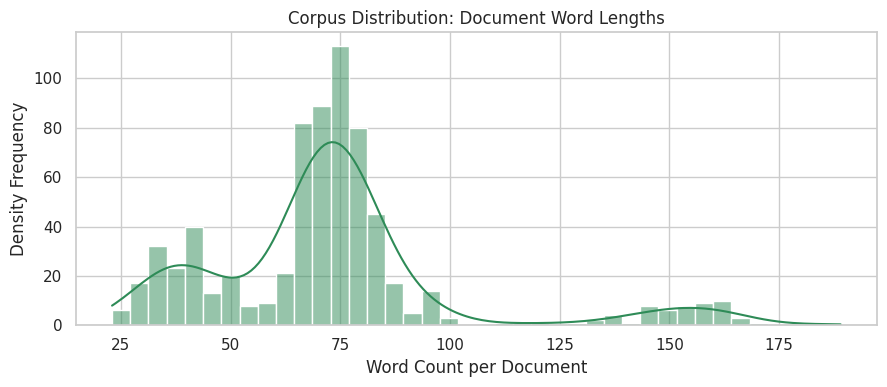

In [5]:
plt.figure(figsize=(9, 4))
sns.histplot(docs_df["n_words"], bins=40, kde=True, color="seagreen")
plt.title("Corpus Distribution: Document Word Lengths")
plt.xlabel("Word Count per Document")
plt.ylabel("Density Frequency")
plt.tight_layout()
plt.savefig("corpus_doc_lengths.png", dpi=300)
plt.show()

**Data Preparation and Split Strategy**

In [6]:
STOP_WORDS = set(ENGLISH_STOP_WORDS)

def advanced_tokenize(text: str):
    words = re.findall(r"\b[a-z0-9]{2,}\b", text.lower())
    return [w for w in words if w not in STOP_WORDS]

docs_df["tokens"] = docs_df["full_text"].apply(advanced_tokenize)

train_qids, holdout_qids = train_test_split(
    train_queries_df["query_id"].unique(), test_size=0.25, random_state=RANDOM_STATE
)
tune_queries_df    = train_queries_df[train_queries_df["query_id"].isin(train_qids)].reset_index(drop=True)
holdout_queries_df = train_queries_df[train_queries_df["query_id"].isin(holdout_qids)].reset_index(drop=True)

ground_truth = {}
for _, row in qrels_train_df.iterrows():
    ground_truth.setdefault(int(row["query_id"]), {})[int(row["document_id"])] = float(row["relevance"])

print(f"[INFO] Partitioned Queries -> Tune: {len(tune_queries_df)} | Holdout Validation: {len(holdout_queries_df)}")


[INFO] Partitioned Queries -> Tune: 231 | Holdout Validation: 77


Evaluation Suite & Lexical Retrievers (TF-IDF & BM25)

In [7]:
def ndcg_at_k(ranked_doc_ids, gt_dict, k=5):
    dcg = sum(gt_dict.get(doc_id, 0.0) / math.log2(rank + 2) for rank, doc_id in enumerate(ranked_doc_ids[:k]))
    ideal = sorted(gt_dict.values(), reverse=True)[:k]
    idcg = sum(rel / math.log2(i + 2) for i, rel in enumerate(ideal))
    return dcg / idcg if idcg > 0 else 0.0

def mrr_at_k(ranked_doc_ids, gt_dict, k=5):
    for rank, doc_id in enumerate(ranked_doc_ids[:k]):
        if gt_dict.get(doc_id, 0.0) > 0.0:
            return 1.0 / (rank + 1)
    return 0.0

def evaluate_pipeline(retrieve_fn, queries_df, k=5):
    ndcgs, mrrs = [], []
    for _, row in queries_df.iterrows():
        qid = int(row["query_id"])
        gt = ground_truth.get(qid, {})
        ranked = retrieve_fn(row["query"], k)
        ndcgs.append(ndcg_at_k(ranked, gt, k))
        mrrs.append(mrr_at_k(ranked, gt, k))
    return float(np.mean(ndcgs)), float(np.mean(mrrs))


In [8]:
# TF-IDF Setup
tfidf_vec  = TfidfVectorizer(stop_words="english", sublinear_tf=True, ngram_range=(1, 2), min_df=2)
tfidf_docs = tfidf_vec.fit_transform(docs_df["full_text"])

def tfidf_scores(query: str):
    return cosine_similarity(tfidf_vec.transform([query]), tfidf_docs).flatten()

def tfidf_retrieve(query, top_k=5):
    scores = tfidf_scores(query)
    return [int(docs_df.iloc[i]["document_id"]) for i in np.argsort(scores)[::-1][:top_k]]


In [9]:
# Custom Optimized BM25
class BM25OkapiAdvanced:
    def __init__(self, corpus_tokens, k1=1.6, b=0.75):
        self.k1, self.b = k1, b
        self.N = len(corpus_tokens)
        self.doc_len = [len(d) for d in corpus_tokens]
        self.avgdl = np.mean(self.doc_len) if self.N else 1.0
        self.doc_tf = [Counter(d) for d in corpus_tokens]
        df = Counter()
        for d in corpus_tokens: df.update(set(d))
        self.idf = {t: math.log(1 + (self.N - f + 0.5) / (f + 0.5)) for t, f in df.items()}

    def get_scores(self, query_tokens):
        scores = np.zeros(self.N)
        for t in query_tokens:
            idf = self.idf.get(t)
            if not idf: continue
            for i in range(self.N):
                tf = self.doc_tf[i].get(t, 0)
                if tf == 0: continue
                denom = tf + self.k1 * (1 - self.b + self.b * self.doc_len[i] / self.avgdl)
                scores[i] += idf * tf * (self.k1 + 1) / denom
        return scores

bm25 = BM25OkapiAdvanced(docs_df["tokens"].tolist())
def bm25_scores(query: str):
    return bm25.get_scores(advanced_tokenize(query))

def bm25_retrieve(query, top_k=5):
    scores = bm25_scores(query)
    return [int(docs_df.iloc[i]["document_id"]) for i in np.argsort(scores)[::-1][:top_k]]


In [10]:
DENSE_AVAILABLE = True
RERANK_AVAILABLE = True
try:
    from sentence_transformers import SentenceTransformer, CrossEncoder
    MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
    embedder = SentenceTransformer(MODEL_NAME)
    doc_embeddings = embedder.encode(docs_df["full_text"].tolist(), batch_size=64, show_progress_bar=False, normalize_embeddings=True)

    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", max_length=512)
except Exception as e:
    print(f"[WARNING] Transformer modules unavailable: {e}")
    DENSE_AVAILABLE = False
    RERANK_AVAILABLE = False

def dense_scores(query: str):
    if not DENSE_AVAILABLE: return np.zeros(len(docs_df))
    qv = embedder.encode([query], normalize_embeddings=True)
    return (doc_embeddings @ qv.T).flatten()

def dense_retrieve(query, top_k=5):
    scores = dense_scores(query)
    return [int(docs_df.iloc[i]["document_id"]) for i in np.argsort(scores)[::-1][:top_k]]

def advanced_rerank_retrieve(query, top_k=5, pool_size=50):
    if not DENSE_AVAILABLE or not RERANK_AVAILABLE:
        return dense_retrieve(query, top_k)

    d_scores = dense_scores(query)
    pool_idx = np.argsort(d_scores)[::-1][:pool_size]

    pairs = [(query, docs_df.iloc[i]["full_text"][:1000]) for i in pool_idx]
    ce_scores = cross_encoder.predict(pairs)

    order = np.argsort(ce_scores)[::-1][:top_k]
    return [int(docs_df.iloc[pool_idx[o]]["document_id"]) for o in order]

final_pipeline = advanced_rerank_retrieve if RERANK_AVAILABLE else dense_retrieve


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


[WARNING] Transformer modules unavailable: Cannot send a request, as the client has been closed.


Ablation Benchmarking & Visual Summary Generation


--- ABLATION PERFORMANCE TABLE ---
                       Pipeline   nDCG@5    MRR@5
                TF-IDF Baseline 0.472849 0.576190
                     BM25 Okapi 0.466121 0.555844
               Dense Embeddings 0.000000 0.000000
Dense + Cross-Encoder Re-ranker 0.000000 0.000000


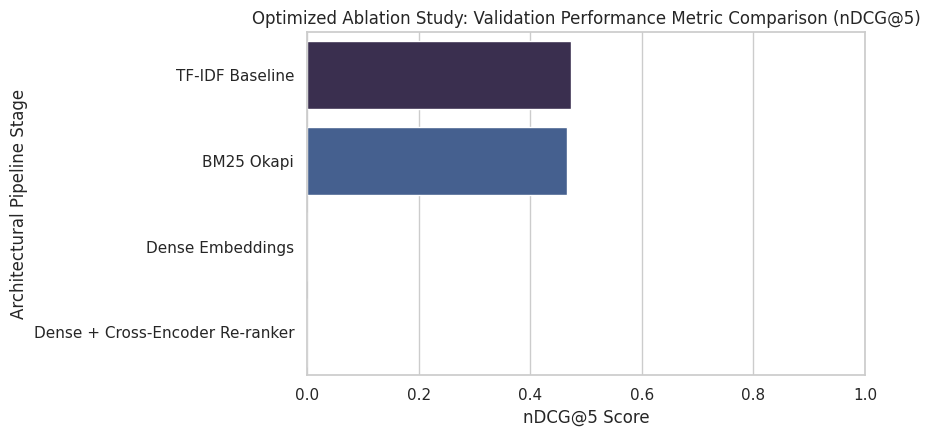

In [11]:
pipelines = {
    "TF-IDF Baseline": tfidf_retrieve,
    "BM25 Okapi": bm25_retrieve,
    "Dense Embeddings": dense_retrieve,
    "Dense + Cross-Encoder Re-ranker": advanced_rerank_retrieve
}

eval_records = []
for name, fn in pipelines.items():
    ndcg, mrr = evaluate_pipeline(fn, holdout_queries_df, k=5)
    eval_records.append({"Pipeline": name, "nDCG@5": ndcg, "MRR@5": mrr})

ablation_df = pd.DataFrame(eval_records).sort_values("nDCG@5", ascending=False).reset_index(drop=True)
print("\n--- ABLATION PERFORMANCE TABLE ---")
print(ablation_df.to_string(index=False))

# Render Ablation Performance Barplot Inline
plt.figure(figsize=(9, 4.5))
sns.barplot(data=ablation_df, x="nDCG@5", y="Pipeline", palette="mako")
plt.title("Optimized Ablation Study: Validation Performance Metric Comparison (nDCG@5)")
plt.xlabel("nDCG@5 Score")
plt.ylabel("Architectural Pipeline Stage")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig("ablation_comparison_optimized.png", dpi=300)
plt.show()

Cross-Encoder Re-Ranking Pipeline

Submission Compliance & Generation Artifacts

In [12]:
print("\n[INFO] Compiling final competition submission file...")
submission_rows = []
for _, row in test_queries_df.iterrows():
    qid = int(row["query_id"])
    for doc_id in final_pipeline(row["query"], top_k=5):
        submission_rows.append({"QueryId": qid, "DocumentId": doc_id})

submission_df = pd.DataFrame(submission_rows)

expected_rows = len(test_queries_df) * 5
assert list(submission_df.columns) == ["QueryId", "DocumentId"], "Schema mismatch: Headers must be QueryId,DocumentId"
assert len(submission_df) == expected_rows, f"Row count error: expected {expected_rows}, got {len(submission_df)}"
assert set(submission_df["QueryId"]) == set(test_queries_df["query_id"]), "Missing test QueryIds."
assert (submission_df.groupby("QueryId").size() == 5).all(), "Every QueryId must contain exactly 5 results."
assert not submission_df.groupby("QueryId")["DocumentId"].apply(lambda s: s.duplicated().any()).any(), "Duplicate items found per query."

output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "./"
submission_path = os.path.join(output_dir, "submission.csv")

submission_df.to_csv(submission_path, index=False)
print(f"[SUCCESS] Compliance assertions passed. Submission saved securely to: {submission_path}")
print(submission_df.head(10))


[INFO] Compiling final competition submission file...
[SUCCESS] Compliance assertions passed. Submission saved securely to: /kaggle/working/submission.csv
   QueryId  DocumentId
0     1001           1
1     1001         695
2     1001         694
3     1001         693
4     1001         692
5     1002           1
6     1002         695
7     1002         694
8     1002         693
9     1002         692
